<a href="https://colab.research.google.com/github/Prajkta11222/Smart-Vehical-Health-Intelligence-and-Predictive-Maintenance-Recommendation-System/blob/main/Vehicle_Health_Model_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Devlopment of a smart Vehical Health Intelligence and Predictive Maintenance Recommendation System


# Libraries

In [6]:
#Install Libraries
!pip install xgboost

In [7]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#Used later to divide data into training and testing sets.
from sklearn.model_selection import train_test_split
#Converts text labels into numeric values.
from sklearn.preprocessing import LabelEncoder
#Scales numerical features when required.
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

#Dataset

In [10]:
#upload dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Smart_Vehicle_Health_Project/dataset/engine_data.csv')


# Exploratory Data Analysis (EDA)


In [12]:
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [13]:
df.shape

(19535, 7)

In [14]:
df.columns

Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp', 'Engine Condition'],
      dtype='object')

In [15]:
df.dtypes

,0
Engine rpm,int64
Lub oil pressure,float64
Fuel pressure,float64
Coolant pressure,float64
lub oil temp,float64
Coolant temp,float64
Engine Condition,int64


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [17]:
df.isnull().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0
Engine Condition,0


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


In [20]:
df["Engine Condition"].value_counts()

,count
Engine Condition,
1,12317
0,7218


In [21]:
df["Engine Condition"].value_counts(normalize=True) * 100

,proportion
Engine Condition,
1,63.050934
0,36.949066


In [22]:
# Calculate correlation between numerical features
corr = df.corr(numeric_only=True)
corr

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
Engine rpm,1.000000,0.025046,-0.001571,-0.024979,0.052134,0.029560,-0.268201
Lub oil pressure,0.025046,1.000000,0.043790,-0.009357,-0.008031,-0.060906,0.060904
Fuel pressure,-0.001571,0.043790,1.000000,0.033264,-0.025338,-0.042986,0.116259
Coolant pressure,-0.024979,-0.009357,0.033264,1.000000,-0.020761,0.033451,-0.024054
lub oil temp,0.052134,-0.008031,-0.025338,-0.020761,1.000000,0.072914,-0.093635
Coolant temp,0.029560,-0.060906,-0.042986,0.033451,0.072914,1.000000,-0.046326
Engine Condition,-0.268201,0.060904,0.116259,-0.024054,-0.093635,-0.046326,1.000000


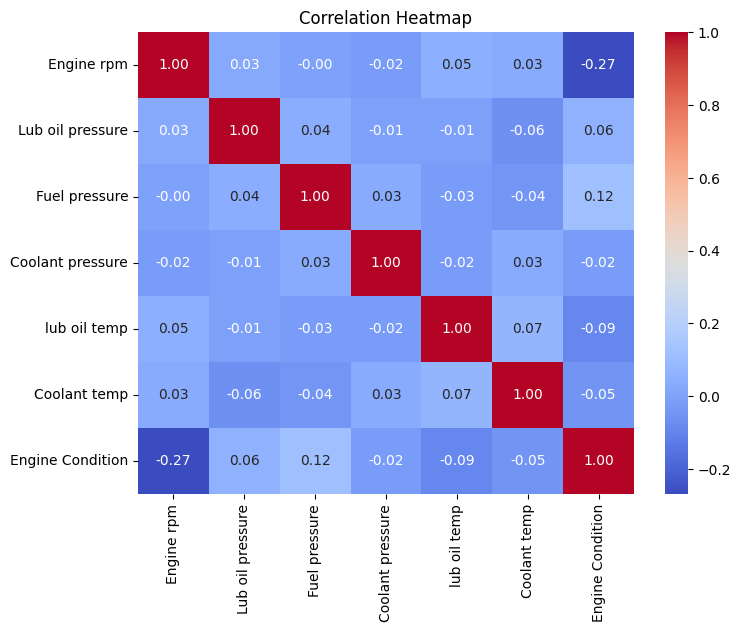

In [23]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

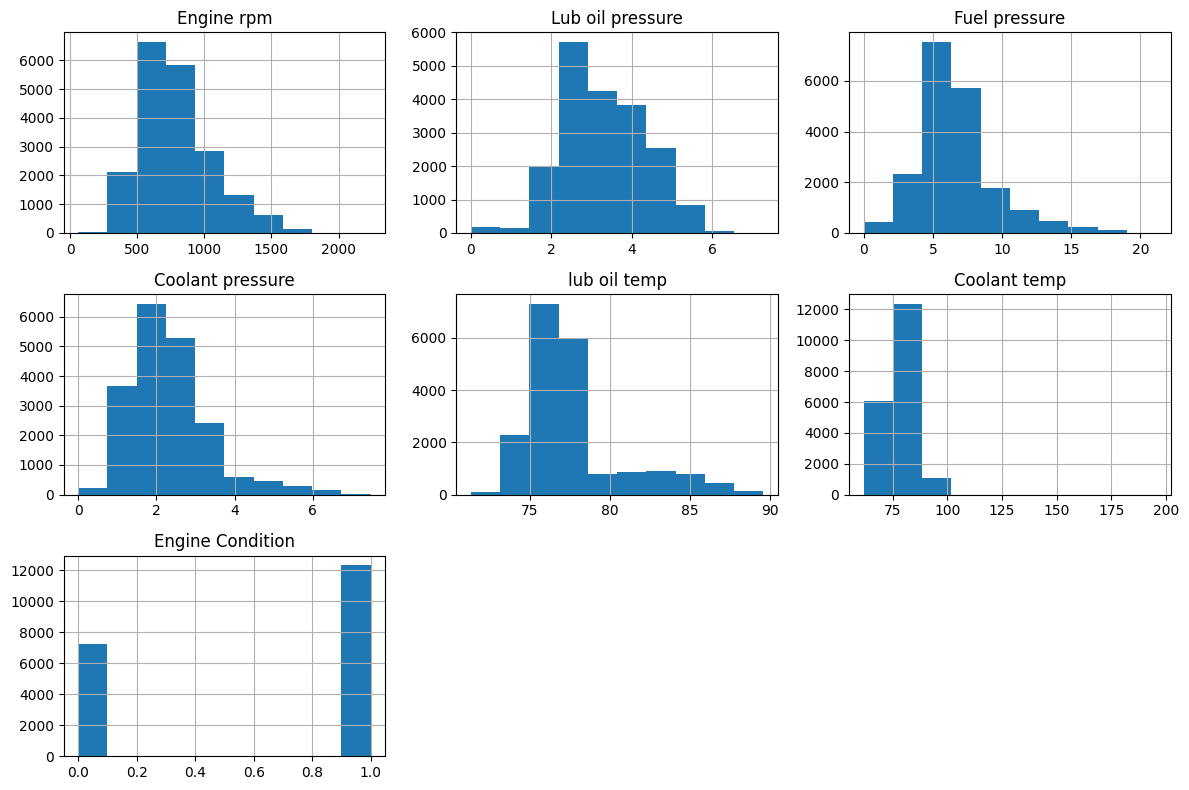

In [24]:
# Plot histograms for all numerical features
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

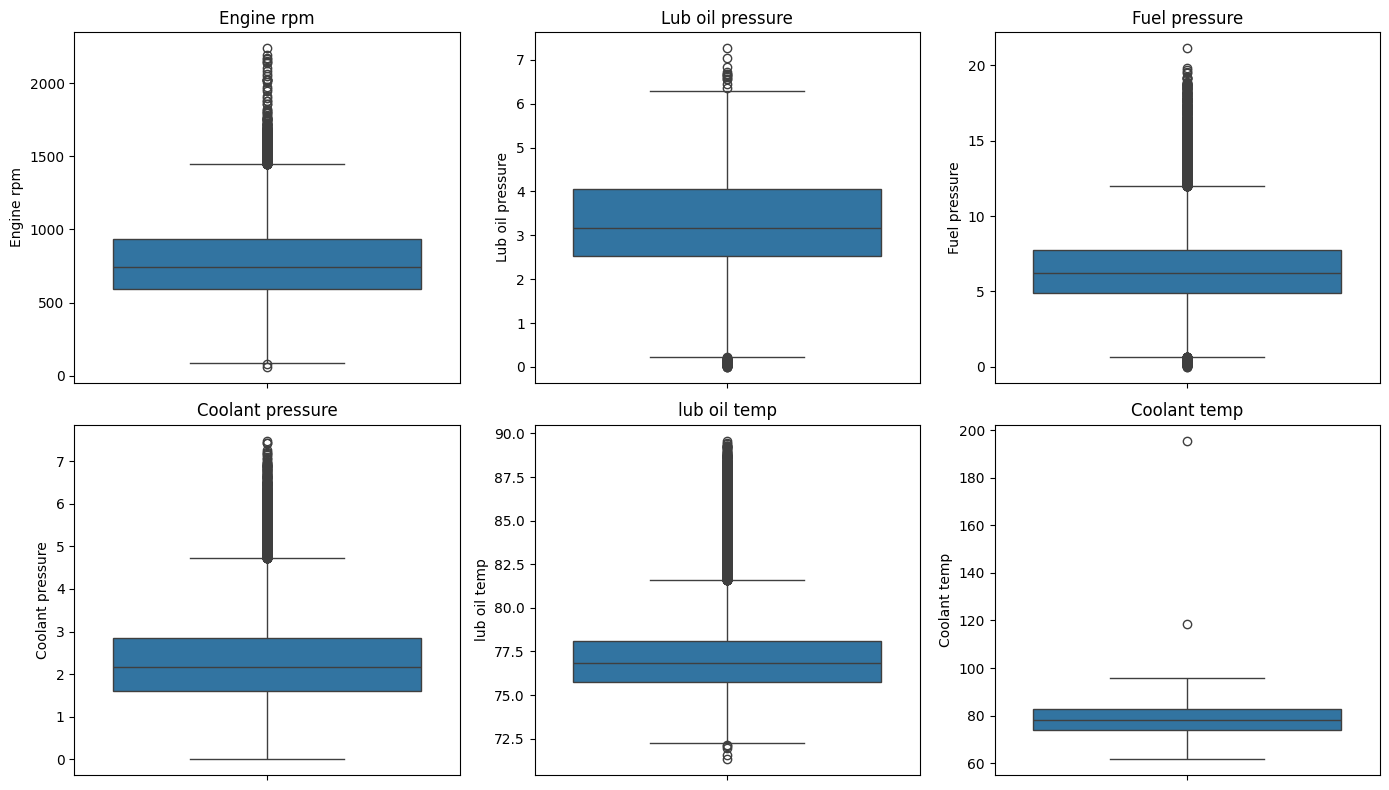

In [25]:
# Plot boxplots to identify potential outliers
plt.figure(figsize=(14,8))

for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

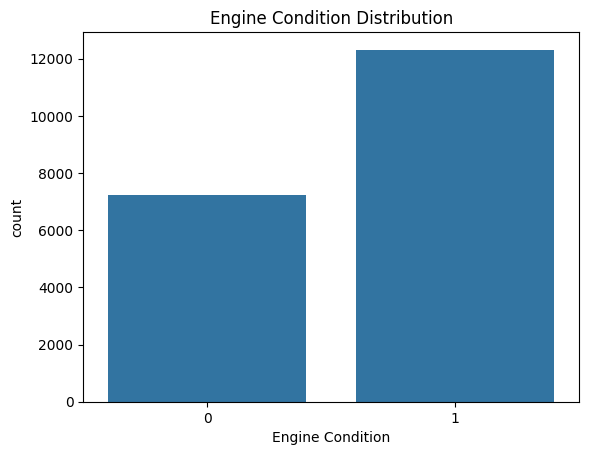

In [26]:
# Visualize the distribution of the target variable
sns.countplot(x="Engine Condition", data=df)
plt.title("Engine Condition Distribution")
plt.show()

#Feature & Target Preparation

In [27]:
# Display the data type of each column
print("Data Types of Each Column:")
print(df.dtypes)

Data Types of Each Column:
Engine rpm            int64
Lub oil pressure    float64
Fuel pressure       float64
Coolant pressure    float64
lub oil temp        float64
Coolant temp        float64
Engine Condition      int64
dtype: object


In [28]:
# Verify that the target column exists
if "Engine Condition" in df.columns:
    print("Target column found.")
else:
    print("Target column NOT found.")

Target column found.


In [29]:
# Separate input features
X = df.drop(columns=["Engine Condition"])

# Separate target variable
y = df["Engine Condition"]

In [30]:
print("First Five Rows of Features (X)")
X.head()

First Five Rows of Features (X)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,700,2.493592,11.790927,3.178981,84.144163,81.632187
1,876,2.941606,16.193866,2.464504,77.640934,82.445724
2,520,2.961746,6.553147,1.064347,77.752266,79.645777
3,473,3.707835,19.510172,3.727455,74.129907,71.774629
4,619,5.672919,15.738871,2.052251,78.396989,87.000225


In [31]:
print("First Five Rows of Target (y)")
y.head()

First Five Rows of Target (y)


,Engine Condition
0,1
1,0
2,1
3,1
4,0


In [32]:
print("Shape of Features")
print(X.shape)

Shape of Features
(19535, 6)


In [33]:
print("Shape of Target")
print(y.shape)

Shape of Target
(19535,)


In [34]:
print("Target Variable Name:")
print(y.name)

print("\nUnique Classes:")
print(y.unique())

Target Variable Name:
Engine Condition

Unique Classes:
[1 0]


In [35]:
print("Original Dataset Shape:")
print(df.shape)

print("Features Shape:")
print(X.shape)

print("Target Shape:")
print(y.shape)

Original Dataset Shape:
(19535, 7)
Features Shape:
(19535, 6)
Target Shape:
(19535,)


# Outlier Detection & Analysis (IQR Method)

In [36]:
# Select only feature columns (exclude target variable)
feature_columns = X.columns

print("Feature Columns:")
print(feature_columns)

Feature Columns:
Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp'],
      dtype='object')


In [37]:
# Detect outliers using the IQR method

import pandas as pd

outlier_summary = []

for column in feature_columns:

    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = X[(X[column] < lower_limit) | (X[column] > upper_limit)]

    outlier_summary.append({
        "Feature": column,
        "Outliers": len(outliers),
        "Percentage": round((len(outliers) / len(X)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Feature,Outliers,Percentage
0,Engine rpm,464,2.38
1,Lub oil pressure,66,0.34
2,Fuel pressure,1135,5.81
3,Coolant pressure,785,4.02
4,lub oil temp,2617,13.40
5,Coolant temp,2,0.01


In [38]:
print("Outlier Summary")
display(outlier_df)

Outlier Summary


,Feature,Outliers,Percentage
0,Engine rpm,464,2.38
1,Lub oil pressure,66,0.34
2,Fuel pressure,1135,5.81
3,Coolant pressure,785,4.02
4,lub oil temp,2617,13.40
5,Coolant temp,2,0.01


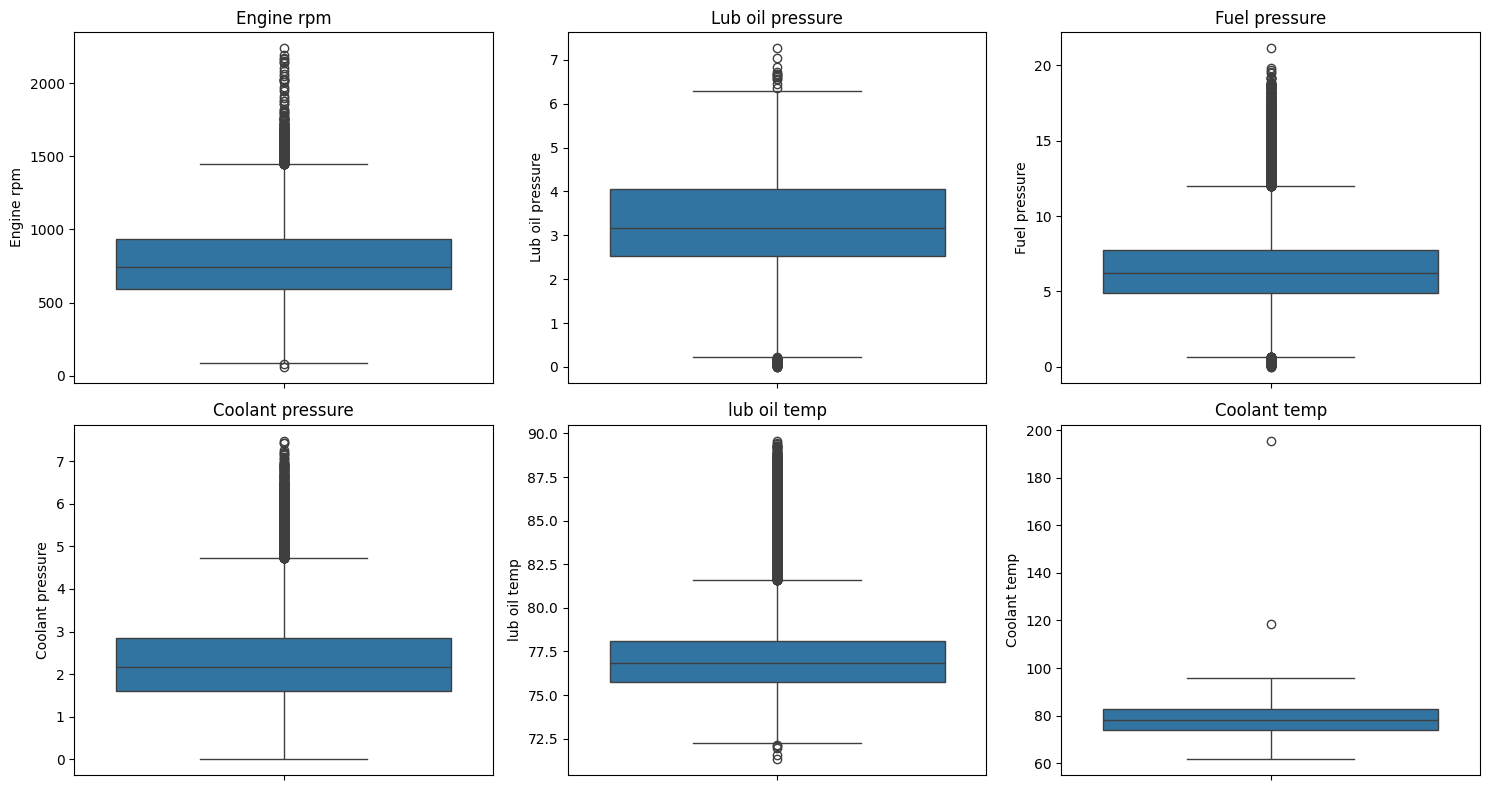

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

for i, column in enumerate(feature_columns):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=X[column])

    plt.title(column)

plt.tight_layout()

plt.show()

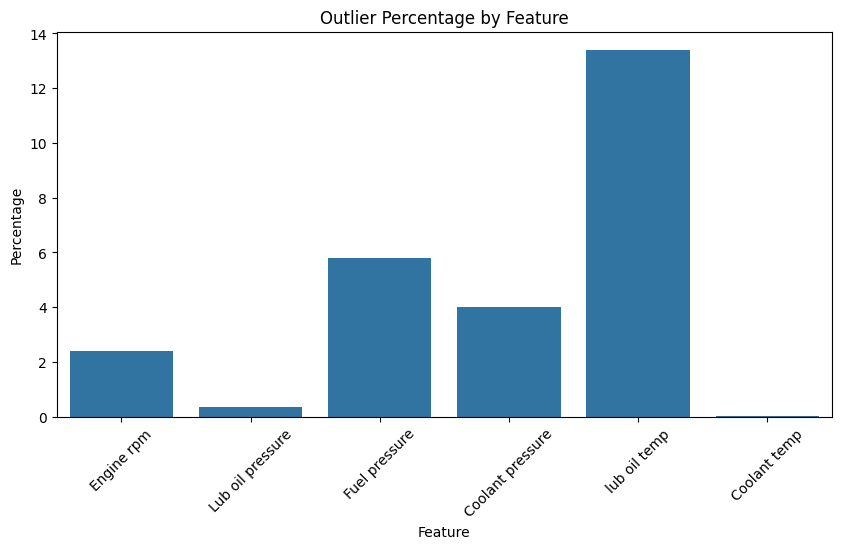

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=outlier_df,
    x="Feature",
    y="Percentage"
)

plt.xticks(rotation=45)

plt.title("Outlier Percentage by Feature")

plt.ylabel("Percentage")

plt.show()

## Conclusion

Outliers were identified using the IQR method and visualized using boxplots. Based on the nature of the vehicle sensor data and the planned Machine Learning algorithms (XGBoost and Random Forest), the detected outliers are retained because they may represent genuine abnormal operating conditions rather than data errors.

# Feature Scaling Decision

In [41]:
print("Feature Scaling Decision")
print("- XGBoost: Scaling Not Required")
print("- Random Forest: Scaling Not Required")
print("- StandardScaler will be used only to create a separate dataset for future comparison models.")

Feature Scaling Decision
- XGBoost: Scaling Not Required
- Random Forest: Scaling Not Required
- StandardScaler will be used only to create a separate dataset for future comparison models.


In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

In [44]:
X_scaled = scaler.fit_transform(X)

In [45]:
import pandas as pd

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [46]:
print("Original Features")
display(X.head())

print("Scaled Features")
display(X_scaled.head())

Original Features


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,700,2.493592,11.790927,3.178981,84.144163,81.632187
1,876,2.941606,16.193866,2.464504,77.640934,82.445724
2,520,2.961746,6.553147,1.064347,77.752266,79.645777
3,473,3.707835,19.510172,3.727455,74.129907,71.774629
4,619,5.672919,15.738871,2.052251,78.396989,87.000225


Scaled Features


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.340948,-0.793040,1.859980,0.814018,2.089663,0.516347
1,0.316739,-0.354506,3.454699,0.124605,-0.000799,0.647423
2,-1.013583,-0.334792,-0.037114,-1.226434,0.034988,0.196298
3,-1.189216,0.395510,4.655845,1.343252,-1.129418,-1.071894
4,-0.643634,2.319014,3.289902,-0.273186,0.242235,1.381240


In [47]:
print("Original Shape:", X.shape)
print("Scaled Shape:", X_scaled.shape)

Original Shape: (19535, 6)
Scaled Shape: (19535, 6)


In [48]:
print(X_scaled.dtypes)

Engine rpm          float64
Lub oil pressure    float64
Fuel pressure       float64
Coolant pressure    float64
lub oil temp        float64
Coolant temp        float64
dtype: object


## Conclusion

Feature scaling was evaluated as part of the preprocessing process. Since the primary Machine Learning models (XGBoost and Random Forest) do not require scaled features, the original feature matrix was preserved. A separate scaled feature matrix (X_scaled) was created only for future comparison with algorithms that benefit from standardized input data.

# Train-Test Split

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [51]:
print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)

print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Feature Shape : (15628, 6)
Testing Feature Shape  : (3907, 6)
Training Target Shape  : (15628,)
Testing Target Shape   : (3907,)


In [52]:
print("Training Set Class Distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Set Class Distribution")
print(y_test.value_counts(normalize=True) * 100)

Training Set Class Distribution
Engine Condition
1    63.053494
0    36.946506
Name: proportion, dtype: float64

Testing Set Class Distribution
Engine Condition
1    63.040696
0    36.959304
Name: proportion, dtype: float64


In [53]:
print("Training Features")
display(X_train.head())

print("Training Target")
display(y_train.head())

Training Features


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
16957,496,4.706240,5.249898,3.803385,75.033607,70.542095
4014,836,3.960027,4.928546,3.705357,74.395016,84.098307
15006,623,3.055244,9.494612,2.084725,76.865701,72.927688
18561,675,2.785797,5.463947,1.649817,75.397279,82.907453
3886,1412,2.816022,4.001410,1.921522,83.246013,71.176927


Training Target


,Engine Condition
16957,0
4014,1
15006,0
18561,1
3886,1


## Conclusion

The dataset has been successfully divided into training and testing sets using an 80:20 ratio. Stratified sampling was applied to maintain the original class distribution of the target variable. The data is now ready for Machine Learning model training.